# **Incompressible Flow Simulation: Tollmien–Schlichting waves**

## Learning Objectives

Welcome to the tutorial on the generating Tollmien–Schlichting waves using incompressible Navier-Stokes solver (IncNavierStokesSolver) in the Nektar++ framework. This tutorial is aimed to show the basic steps to excite two-dimensional flow instabilities inside the boundary layer for further analysis. After the completion of this tutorial, you will be familiar with:

- the excitation of flow instabilities using blowing-suction defined on the wall;
- the settings to run the linearized incompressible flow solver;
- simulating the development of T-S waves.

## Introduction
Flow transition is the process where laminar flow becomes turbulent flow. When the freestream turbulence intensity is low, a laminar boundary layer flow experiences natural transition to become turbulence. The natural transition is featured by the linear growth of disturbances, among which the most famous pattern is Tollmien–Schlichting (T-S) waves.

In this tutorial we are going to simulate T-S waves inside a 2D flat plate boundary layer. We first generate a steady baseflow using the incompressible flow solver. Then, we compute the perturbation fields with respect to the baseflow. To compute the linear growth of the T-S waves, we will use the linearized incompressible flow solver for higher efficiency. This linearized incompressible flow solver is a routine in the incompressible flow solver in **Nektar++**. We will also introduce how to turn on this solver in this tutorial. 

As for the T-S wave excitation, a little part of the wall is defined for blowing-suction, which perturbs the flow fields at a given frequency. The disturbance frequency is a key parameter for all kind of instabilities. The instability with a frequency outside certain ranges will not be amplified but damped in the selected spatial domain. The frequency ranges can be computed through linear stability analysis, for which **Nektar++** has a FieldConvert module. The use of this module will be introduced in a following tutorial.

## Geometry parameters

We are going to simulate the T-S wave over a flat plate as shown in the sketch below, where the start and end streamwise coordinates, $x_{0} = 0.19$ [m] and $x_1 = 1.05$ [m]. However, for the demonstration purpose, we truncate the domain for higher efficiency and the following coordinates are used

* $x_0 = 0.19$ [m]
* $x_1 = 0.40$ [m]

In the wall normal direction, we use

* $y_0 = 0.00$ [m]
* $y_1 = 0.04$ [m]

The reference length we use is

* $L_{ref} = 0.165$ [m]

<table> <tr> 
    <td> <img src="./image/disturbance_strip.png" width="500" height ="300"/> Sketch of the case </td> 
</tr> </table>

<div class="alert alert-info">

**Note:** If the users would like to have a full simulation on their own machines, they can generate a mesh with full domain in *Gmsh* and then use *NekMesh* to generate the mesh file in *xml* extension.

</div>



## Flow parameters

The fluid/flow parameters in this tutorial are

* $\nu = 1.51 \times 10^{-5} $ [m$^2$/s]
* $U_{\infty} = 9.18$ [m/s]
* $Re = \frac{U_{\infty}L_{ref}}{\nu} = 1.0 \times 10^5$

The parameters related to blowing-suction are free to be defined. For simplicity, we define the amplitude and frequency as. 

* $Amplitude = 0.0003$ [m/s] 
* $f      = 96.4$ [Hz]


<div class="alert alert-warning">

**Note:** We are not going to scale this case but keep the physical values for all the parameters.

</div>

# Solving for baseflow

## Session file

We will use two different session files for baseflow computation and pertubation field simulation, respectively. Since the baseflow is typically a 2D flow, please refer to the tutorial `Incompressible Flow Simulation` for more details. We will introduce the key differences to set up the case. 

The baseflow is 2D flat plate boundary layer flow. As is used in many simulations, the Blasius profile is applied for the inflow boundary. The profile is obtained by solving the Blasius equation for self-similar profile $f(\eta)$

$$ f^{'''} + \frac{1}{2} f f^{''}= 0 $$

where 

$$ \eta = \sqrt{\frac{U_{\infty}}{\nu x}} y $$

The boundary conditions at $\eta=0$ and $\eta = \infty$ are

$$ f(0) = 0 \quad  f^{'}(0) = 0 \quad f^{'}(\infty) = 1 $$



<div class="alert alert-info">

**Note:** Note that $f$ and $\eta$ are dimensionless

</div>




The expression for velocity components are

$$ u(x,y) = U_{\infty} f^{'}(\eta)$$

$$ v(x,y) = \frac{1}{2} U_{\infty} {Re_x}^{-1/2} \left( \eta f^{'} - f \right)$$


To impose the Blasius profile at inflow, we pre-solved this equation and interpolated the velocity components using 8th-prder polynomials with a fixed zero for constant term. The relations for $\eta - f^{'}$ and $\eta - \left( \eta f^{'} - f \right)$ is interpolated instead of $y-u$ and $y-v$ to reduce interpolation error. The profile is interpolated up to $\eta = 10$ is enough since the velocity profile reaches $0.99 U_{\infty}$ at about $\eta = 7$. However, we use $\eta_{max} = 9$ to aviod the minor wiggle at the end. Finally, the profile related parameters are as follows. Please [Open up the session file](baseSession.xml) and navigate to the `PARAMETERS` tag to fill in the missing parameters.


```xml
    <PARAMETERS>
      <P> Re              = 100000       </P>
      <P> Uinf            = 9.18         </P>
      <P> Vinf            = 0.02328497   </P> <!--v component velocity at large y at inflow boundary-->
      <P> Lref            = 0.165        </P>
      <P> Kinvis          = Uinf*Lref/Re </P>  
        
      <P> x0_dim          = 0.19                     </P> <!--[m], x for inflow boundary-->  
      <P> y2eta           = sqrt(Uinf/Kinvis/x0_dim) </P> <!--1/[m], y*y2eta=eta-->  
      <P> etaMax          = 9.0                      </P>
      <P> y_etaMax        = etaMax/y2eta             </P> <!--[m]-->

      <P> c0_u            = -7.588793192637297e-07   </P> <!--These coeff are for eta to df/deta, no need to change -->
      <P> c1_u            = 3.194022625802455e-05    </P>
      <P> c2_u            = -5.359224544180487e-04   </P>
      <P> c3_u            = 0.004456471192420        </P>
      <P> c4_u            = -0.018001543100935       </P>
      <P> c5_u            = 0.026349808614288        </P>
      <P> c6_u            = -0.019383436111100       </P>
      <P> c7_u            = 0.336425284918826        </P>
 
      <P> c0_v            = -1.973915433977048e-06   </P>
      <P> c1_v            = 9.301500235002117e-05    </P>
      <P> c2_v            = -0.001775056424737       </P>
      <P> c3_v            = 0.017278644240805        </P>
      <P> c4_v            = -0.086928463802734       </P>
      <P> c5_v            = 0.185965415918227        </P>
      <P> c6_v            = -0.010699737058846       </P>
      <P> c7_v            = 0.054417998357595        </P>
    </PARAMETERS>
```

Having these parameters obtained, we can impose the expression for inflow as follows. Defining different expressions in different intervals on the same boundary is supported. For example, in the inflow boundary condition, we defined a Blasius profile for $y<y\_etaMax$ and a constant $U_{\infty}$ for $ y \geq y\_etaMax$. Please open the [session file](baseSession.xml) and fill in the missing terms.

```xml
    <BOUNDARYCONDITIONS>     
      <REGION REF="2">                    
        <D VAR="u" VALUE="Uinf*((c0_u*(y*y2eta)^8 + c1_u*(y*y2eta)^7 + c2_u*(y*y2eta)^6 + c3_u*(y*y2eta)^5 
                               + c4_u*(y*y2eta)^4 + c5_u*(y*y2eta)^3 + c6_u*(y*y2eta)^2 + c7_u*(y*y2eta))
                         *(y<y_etaMax) + (y>=y_etaMax))" />
        <D VAR="v" VALUE="0.5*Uinf*(Uinf*x0_dim/Kinvis)^(-0.5)*
                                (c0_v*(y*y2eta)^8 + c1_v*(y*y2eta)^7 + c2_v*(y*y2eta)^6 + c3_v*(y*y2eta)^5 
                               + c4_v*(y*y2eta)^4 + c5_v*(y*y2eta)^3 + c6_v*(y*y2eta)^2 + c7_v*(y*y2eta))
                         *(y<y_etaMax) + Vinf*(y>=y_etaMax)" />
        <N VAR="p" USERDEFINEDTYPE="H" VALUE="0" />
      </REGION>  
    </BOUNDARYCONDITIONS>
```


We can check the inflow profile using the following code.

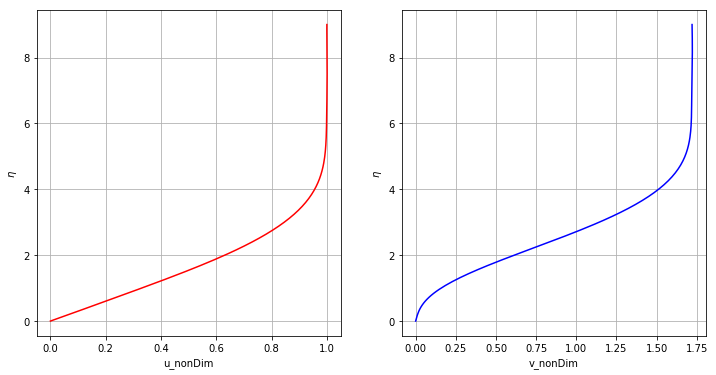

In [6]:
import numpy as np
import matplotlib.pyplot as plt

etaMax = 9.0 # No larger than 10.0 

c0_u   = -7.588793192637297e-07
c1_u   =  3.194022625802455e-05
c2_u   = -5.359224544180487e-04
c3_u   =  0.004456471192420
c4_u   = -0.018001543100935
c5_u   =  0.026349808614288
c6_u   = -0.019383436111100
c7_u   =  0.336425284918826

c0_v   = -1.973915433977048e-06
c1_v   =  9.301500235002117e-05
c2_v   = -0.001775056424737
c3_v   =  0.017278644240805
c4_v   = -0.086928463802734
c5_v   =  0.185965415918227
c6_v   = -0.010699737058846
c7_v   =  0.054417998357595

nPts   = 150 + 1
dEta   = etaMax/(nPts-1)
eta    = np.zeros(nPts)
uNon   = np.zeros(nPts)
vNon   = np.zeros(nPts)

for i in range(0,nPts):
    eta[i]  = i*dEta
    uNon[i] = c0_u*eta[i]**8 + c1_u*eta[i]**7 + c2_u*eta[i]**6 + c3_u*eta[i]**5 \
            + c4_u*eta[i]**4 + c5_u*eta[i]**3 + c6_u*eta[i]**2 + c7_u*eta[i]
    vNon[i] = c0_v*eta[i]**8 + c1_v*eta[i]**7 + c2_v*eta[i]**6 + c3_v*eta[i]**5 \
            + c4_v*eta[i]**4 + c5_v*eta[i]**3 + c6_v*eta[i]**2 + c7_v*eta[i]

plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.plot(uNon,eta,'r-')
plt.xlabel('u_nonDim')
plt.ylabel('$\eta$')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(vNon,eta,'b-')
plt.xlabel('v_nonDim')
plt.ylabel('$\eta$')
plt.grid(True)

## Running the solver
As everything is now set you can run the solver by executing the following cell:

<div class="alert alert-warning">

**Note:** If things don't run or you get errors, [have a look at the completed session file](baseSession-Complete.xml) and check to see if you've got any differences or mistakes!

</div>

In [ ]:
!IncNavierStokesSolver TSMesh.xml baseSession.xml

We can rename the baseflow file for perturbation simulation.
<div class="alert alert-info">

**Note:** This step is optional. It is done to make the purpose of the file clearer.

</div>

In [8]:
!mv TSMesh.fld base_P4.fld

# Solving for perturbation fields
## Session file

Having obtained the baseflow, we will compute the perturbation fields with a different settings in the session file. An available choice is to copy the baseflow session file and modify part of it. The advantage for doing so is making sure a backp is there. In this [new session file](pertSession.xml) we need to change the `EvolutionOperator` from the default `Nonlinear` (if not specified) to `Direct` to run the linear solver. 

When you are done, the `SOLVERINFO` section should look like:

```xml
    <SOLVERINFO>
      <I PROPERTY="EvolutionOperator"                    VALUE="Direct"                     />
      <I PROPERTY="Driver"                               VALUE="Standard"                   />
    </SOLVERINFO>
```
Under the `PARAMETERS` tag, the parameters for disturbance strip is preferred to be defined for expression simplicity in boundary condition settings. The completed [session file](pertSession.xml) should have the following parameter settings

```xml
    <PARAMETERS>
      <P> f               = 96.4                     </P> <!--[Hz]-->
      <P> Amplitude       = 0.0003                   </P> 
      <P> x_strip         = 0.25                     </P> <!--[m], left end of the blowing-suction-->
      <P> span            = 0.003                    </P> <!--[m], span of the blowing-suction in x direction-->
    </PARAMETERS>
```

As for the boundary condition, we directly let part of the wall to vibrate according to the defiend parameters to excite the instability. To use a time-dependent expression for blowing-suction, `USERDEFINEDTYPE`="TimeDependent" is needed. The Dirichlet boundary condition for velocity components at inflow now need to be set zero. Now update the [session file](pertSession.xml) according to the follwoing settings.

```xml
    <BOUNDARYCONDITIONS>
      <!-- Wall -->
      <REGION REF="0"> 
        <D VAR="u" VALUE="0" />
        <D VAR="v" USERDEFINEDTYPE="TimeDependent" 
                   VALUE="Amplitude*sin(2*PI/span*(x-x_strip))*sin(2*PI*f*t)*(x>=x_strip)*(x<=(x_strip+span))" />
        <N VAR="p" USERDEFINEDTYPE="H" VALUE="0" />
      </REGION>
      <!-- Inflow -->
      <REGION REF="2"> 
        <D VAR="u" VALUE="0" />
        <D VAR="v" VALUE="0" />
        <N VAR="p" USERDEFINEDTYPE="H" VALUE="0" />
      </REGION>
    </BOUNDARYCONDITIONS>
```

Finally, the last modification is to add a function called `BaseFlow`, where the baseflow file is specified for the solver. Please fill in the file name in the [session file](pertSession.xml)
```xml
    <FUNCTION NAME="BaseFlow">
      <F VAR="u,v,p" FILE="base_P4.fld"   />
    </FUNCTION>
```

## Running the solver
As everything is now set you can run the linearised incompressible Navier-Stokes solver by executing the following cell:

<div class="alert alert-warning">

**Note:** If things don't run or you get errors, [have a look at the completed session file](pertSession-Complete.xml) and check to see if you've got any differences or mistakes!

</div>

In [ ]:
!IncNavierStokesSolver TSMesh.xml pertSession.xml

## Visualising the T-S waves

The cells below show how visualisation of a VTU output file from `FieldConvert` can be viewed directly in the notebook. First, we post-process with FieldConvert to produce a .vtu file.

In [ ]:
!mv TSMesh.fld pert_P4.fld
!FieldConvert -f TSMesh.xml pertSession-Complete.xml pert_P4.fld pert.vtu

In [ ]:
import pyvista as pv

# First read the VTK file
mesh = pv.read('pert.vtu')

# Now create an itkwidget to visualise this in-browser.
pl = pv.PlotterITK()
pl.add_mesh(mesh, scalars=mesh['u'], smooth_shading=True)
pl.show(True)

## Extra tasks 

We have some exercise here to help you master how to do the T-S wave simulations. Lets do it together:

### <span style="color:Chocolate"><b> Task 1   </b> </span> 
Run the simulation with a disturbance frqeuency $f=110$ [Hz], and find out how the amplitude of u-field compares with the original one. You will set `<P> f = 110.0 </P>` under the `PARAMETERS` tag.

### <span style="color:Chocolate"><b> Task 2   </b> </span> 
Currently the disturbance strip is placed at $x=0.25$ [m]. Try to move it to $x = 0.3$ [m] and extend its streamwise length a bit to $0.005$ [m]. You will set `<P> x_strip = 0.3 </P>` and `<P> length = 0.005 </P>` under the `PARAMETERS` tag.


### <span style="color:Chocolate"><b> Task 3   </b> </span> 
In a linearized flow solver, the amplitudes of velocity components can be scaled simultaneously. You can increase the amplitude of the disturbance to be ten times larger by setting `<P> Amplitude = 0.003 </P>`. Run the simulation again and see if the scaled amplification curve lies on top of each other. The amplification curve can be obtained by taking a slice in a post-processing software such as Paraview and Tecplot.




### <span style="color:Chocolate"><b> Task 4   </b> </span> 
The expansion order has a influence on the resolution in the spectral/hp element method. Using the given mesh, find out the lowest expansion order needed to correctly resolve the T-S wave.


<div class="alert alert-warning">

**Note:** When the expansion order is increased, you might need a smaller time step to keep the simulation stable. The time step can be set in `<P> TimeStep = 3.0e-5 </P>` under the `PARAMETERS` tag.

</div>


## Take-a-ways  <a id='takeaways'> </a>
It is worth keeping in mind the following points:

- `EvolutionOperator` needs to be changed to `Direct` to run the linearized NS solver.
- Baseflow for the linearized NS solver is input through `FUNCTION` named "BaseFlow".
- Different expressions can be specified on the same boundary by multiplying the range, e.g. $u_0*(x \le 1) + u_1*(x>1)$. 

### End of the tutorial. 